In [ ]:
!pip install ultralytics

In [ ]:
## Project Explanation

This project uses YOLOv8 to detect:
- Rider
- Helmet
- No Helmet
- Number Plate

The system identifies safety violations and can be extended to IoT alert systems.

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

In [ ]:
model = YOLO("yolov8n.pt")

In [14]:
pip install ultralytics

Note: you may need to restart the kernel to use updated packages.


In [15]:
import ultralytics
ultralytics.checks() 

Ultralytics 8.4.41 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6845.8/8062.4 GB disk)


In [16]:
from glob import glob
from itertools import chain
from collections import Counter
from pprint import pprint

id2class_map = {
    '0': 'with helmet', 
    '1': 'without helmet', 
    '2': 'rider', 
    '3': 'number_plate'
}
main_path = "/kaggle/input/rider-with-helmet-without-helmet-number-plate"  

def print_data_size(folder_type):
    data_size = len(glob(f'{main_path}/{folder_type}/labels/*.txt'))
    print(f'{folder_type} data count: {data_size}')
    
def print_class_count(folder_type):
    class_list = []
    for file in glob(f'{main_path}/{folder_type}/labels/*.txt'):
        class_list.append([row.split()[0] for row in open(file, "r")])
    counter = Counter(list(chain(*class_list)))
    print(f'-- data class count')
    pprint({f'{k}. {id2class_map[k]}':v for k, v in counter.items()})
    print()

print_data_size('train')
print_class_count('train')
print_data_size('val')
print_class_count('val')  

{'0. with helmet': 64,
 '1. without helmet': 93,
 '2. rider': 120,
 '3. number_plate': 116}


{'0. with helmet': 13,
 '1. without helmet': 15,
 '2. rider': 23,
 '3. number_plate': 22}


train data count: 104
-- data class count
{'0. with helmet': 64,
 '1. without helmet': 93,
 '2. rider': 120,
 '3. number_plate': 116}

val data count: 20
-- data class count
{'0. with helmet': 13,
 '1. without helmet': 15,
 '2. rider': 23,
 '3. number_plate': 22}



{'0. with helmet': 13,
 '1. without helmet': 15,
 '2. rider': 23,
 '3. number_plate': 22}

In [17]:
import os
import cv2
from matplotlib import pyplot as plt

main_path = f"/kaggle/input/rider-with-helmet-without-helmet-number-plate"  

def get_bbox_and_label(image_name, data_type='train', main_path=main_path):
    ''' get bbox and label information from label txt files '''
    
    # read file from path
    lbl_path = os.path.join(main_path, data_type, 'labels', f'{image_name}.txt')
    with open(lbl_path, 'r') as f:
        lines = f.readlines()
    
    # extract bboxes and labels from the label file
    bboxes = [
        [float(n) for n in line.split()[1:]]
        for line in lines
    ]
    labels = [id2class_map[line.split()[0]] for line in lines]
    
    return bboxes, labels
    
def load_image(image_name, data_type='train', main_path=main_path):
    img_path = os.path.join(main_path, data_type, 'images', f'{image_name}.jpg')    
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

def get_bbox_coordinates(img, bbox):
    img_height, img_width, _ = img.shape
    x_center, y_center, bbox_width, bbox_height = bbox
    
    # calculate the coordinates of the bounding box
    x_center_pixel = x_center * img_width
    y_center_pixel = y_center * img_height
    half_width = bbox_width * img_width / 2
    half_height = bbox_height * img_height / 2
    
    x_min = int(x_center_pixel - half_width)
    y_min = int(y_center_pixel - half_height)
    x_max = int(x_center_pixel + half_width)
    y_max = int(y_center_pixel + half_height)
    
    return x_min, y_min, x_max, y_max

class2color_map = {
    'with helmet': (0,255,128),
    'without helmet': (255,51,51),
    'rider': (51,255,255),
    'number_plate': (224,102,255)
}

def plot_image(image_name, data_type='train', class2color_map=class2color_map):
    img = load_image(image_name=image_name, data_type=data_type)
    bboxes, labels = get_bbox_and_label(image_name=image_name, data_type=data_type)
    for bbox, label in zip(bboxes, labels):
        
        # get bbox and label info
        color = class2color_map[label]
        x_min, y_min, x_max, y_max = get_bbox_coordinates(img, bbox)
        
        # add bounding box with rectangle
        img = cv2.rectangle(img,(x_min,y_min),(x_max,y_max), color, 2)
        
        # add label info
        img = cv2.putText(
                img,
                label,
                (x_min, y_min + 10),
                fontFace = cv2.FONT_HERSHEY_SIMPLEX,
                fontScale = 0.6,
                color = color,
                thickness=2
            )
    plt.imshow(img)
    plt.show()

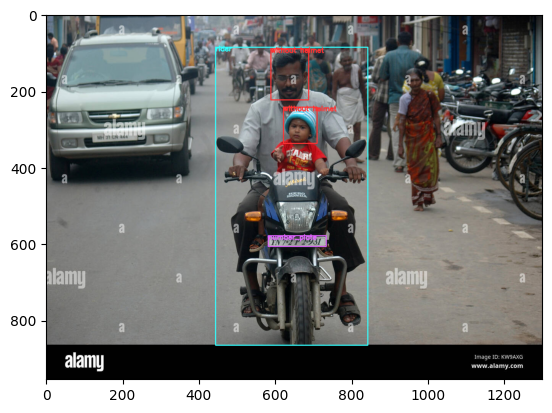

In [18]:
plot_image(image_name='new100')

In [19]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLOv8n model
model = YOLO('yolov8n.pt')

# Display model information 
model.info()

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

In [20]:
import yaml

# read the content of coco128.yaml
with open(os.path.join(main_path, 'coco128.yaml'), 'r') as file:
    print(file.read())

train: /train/images
val: /val/images

nc: 4

names: ["with helmet", "without helmet", "rider", "number plate"]


In [21]:
# creata the yaml based on coco128 for model training
data = {
    'train': '/kaggle/input/rider-with-helmet-without-helmet-number-plate/train',
    'val': '/kaggle/input/rider-with-helmet-without-helmet-number-plate/val',
    'nc': 4,
    'names': [
        'with helmet',
        'without helmet',
        'rider',
        'number plate'
    ]
}

with open('/kaggle/working/data.yaml', 'w') as file:
    yaml.dump(data, file)

# check the content of data.yaml
with open('/kaggle/working/data.yaml', 'r') as file:
    print(file.read())

names:
- with helmet
- without helmet
- rider
- number plate
nc: 4
train: /kaggle/input/rider-with-helmet-without-helmet-number-plate/train
val: /kaggle/input/rider-with-helmet-without-helmet-number-plate/val



In [ ]:
with open("data.yaml", "w") as f:
    f.write("""
train: /kaggle/input/rider-with-helmet-without-helmet-num/train/images
val: /kaggle/input/rider-with-helmet-without-helmet-num/val/images

nc: 4

names:
  0: rider
  1: with helmet
  2: without helmet
  3: number plate
""")

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=8
)

Ultralytics 8.4.41 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all         20         73      0.936      0.914      0.949      0.795
           with helmet         12         13      0.985      0.846      0.919      0.693
        without helmet         10         15       0.79      0.933      0.928      0.791
                 rider         20         23      0.971      0.913      0.954      0.892
          number plate         20         22          1      0.963      0.995      0.806
Speed: 0.2ms preprocess, 2.2ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /kaggle/working/runs/detect/train-2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7919d413d590>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
model.predict(
    source="/kaggle/input/rider-with-helmet-without-helmet-num/val/images/sample.jpg",
    show=True
)

In [ ]:
model.val()

In [ ]:
model.save("smart_helmet_model.pt")

In [ ]:
results = model.predict(
    source="/kaggle/input/rider-with-helmet-without-helmet-num/val/images",
    save=True
)

In [ ]:
from IPython.display import Image, display
import os

output_folder = "runs/detect/predict"

for img in os.listdir(output_folder):
    display(Image(filename=f"{output_folder}/{img}"))

In [23]:
# select the best model for checking prediction plot
# the model is saved in best.pt directly after training
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')

In [ ]:
def plot_pred_image(image_name, id2class_map=id2class_map, class2color_map=class2color_map):
    image_path = os.path.join(main_path, 'val', 'images', f'{image_name}.jpg')
    results = model.predict("/kaggle/input/rider-with-helmet-without-helmet-num/val/images/sample.jpg", show=True)
    r = results[0]
    img = r.orig_img.copy()

    bboxes = r.boxes.xyxy.tolist()
    class_ids = r.boxes.cls.tolist()
    confs = r.boxes.conf.tolist()

    for bbox, cls_id, conf in zip(bboxes, class_ids, confs):
        label = id2class_map[str(int(cls_id))]
        color = class2color_map[label]
        x_min, y_min, x_max, y_max = [int(n) for n in bbox]

        img = cv2.rectangle(img, (x_min, y_min), (x_max, y_max), color, 2)
        img = cv2.putText(
            img,
            f"{label} {conf:.2f}",
            (x_min, max(20, y_min - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

In [ ]:
import matplotlib.pyplot as plt

img = cv2.imread("/kaggle/input/rider-with-helmet-without-helmet-num/val/images/sample.jpg")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

In [ ]:
model.export(format="onnx")

prediction ↓

image 1/1 /kaggle/input/rider-with-helmet-without-helmet-number-plate/val/images/new113.jpg: 640x576 2 with helmets, 1 rider, 8.4ms
Speed: 2.6ms preprocess, 8.4ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 576)


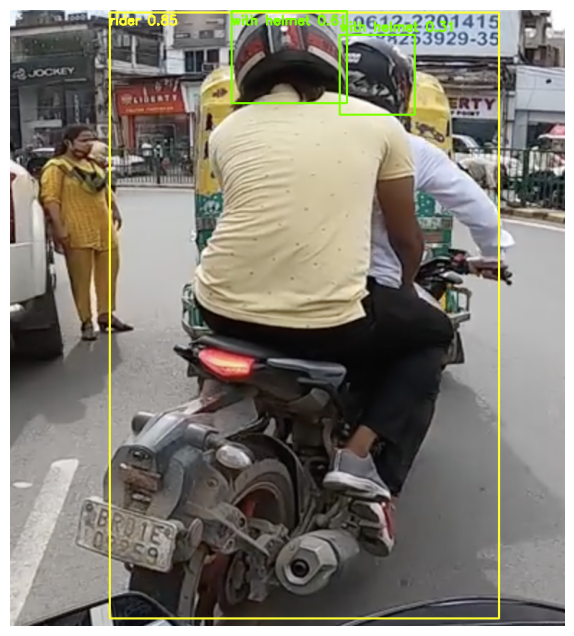

actual image ↓


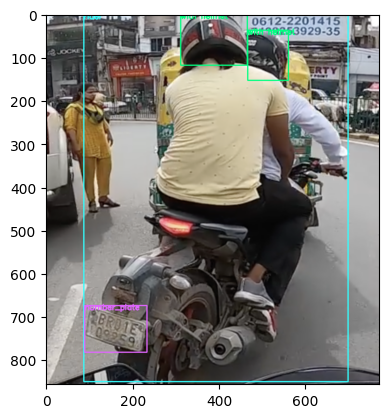

In [25]:
image_name = 'new113'
print('prediction ↓')
plot_pred_image(image_name=image_name)
print('actual image ↓')
plot_image(image_name=image_name, data_type='val')


In [ ]:
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    results = model(frame)

    annotated = results[0].plot()
    cv2.imshow("Helmet Detection", annotated)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [ ]:
metrics = model.val()
print(metrics)

In [ ]:
## 🚧 Smart Helmet Detection System

This project uses YOLOv8 to detect:
- Rider
- Helmet
- No Helmet
- Number Plate

### Workflow:
1. Dataset loaded from Kaggle
2. Data configured using data.yaml
3. Model trained using YOLOv8
4. Predictions made on validation images

### Use Case:
Can be used in:
- Traffic monitoring
- Construction safety
- Smart IoT alert systems